# Plotting — matplotlib + seaborn cheatsheet


Use matplotlib for fine control. Use seaborn for quick statistical plots (boxplots, heatmaps, pairplots, distributional). The two compose: seaborn returns matplotlib axes you can further customise.

**The single most important habit**: always do `fig, ax = plt.subplots(...)` and call methods on `ax`. The pyplot-state (`plt.plot`, `plt.title`, ...) interface works for one-off scripts but breaks down with multi-panel figures and subplots.


---
## Setup

Run this once.


### Setup — run me first


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

rng = np.random.default_rng(0)

# Tiny synthetic data used by every example.
ts = pd.date_range('2024-01-01', periods=200, freq='1h', tz='UTC')
returns = pd.Series(rng.normal(0, 1, len(ts)), index=ts)
prices = pd.Series(100 + returns.cumsum(), index=ts)

df_long = pd.DataFrame({
    'symbol': np.repeat(['A', 'B', 'C'], 100),
    'value':  np.concatenate([rng.normal(0, 1, 100), rng.normal(0.3, 1, 100), rng.normal(-0.1, 1.5, 100)]),
    'group':  np.tile(['x', 'y'], 150),
})

---
## 1. The `fig, ax = plt.subplots()` pattern

Every plot starts with `fig, ax = plt.subplots(...)`. After that you call methods on `ax`. End with `plt.tight_layout(); plt.show()`.


### How do I make a basic line plot?

Open a figure, plot, set labels, show. The five lines below are the canonical skeleton.


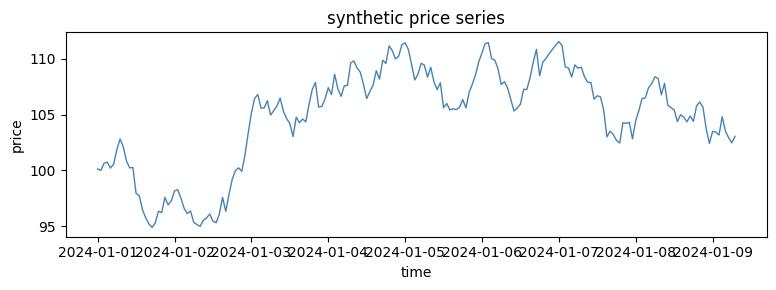

In [2]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(prices.index, prices.values, color='steelblue', lw=1)
ax.set_xlabel('time')
ax.set_ylabel('price')
ax.set_title('synthetic price series')
plt.tight_layout(); plt.show()

*Why fig, ax over plt.plot*: when you eventually need two panels, you'll be able to swap `subplots()` → `subplots(1, 2)` and reuse all the `ax.*` lines verbatim. The pyplot-state version doesn't generalise. *Common mistake*: forgetting `plt.show()` — in scripts the figure won't display; in notebooks it usually shows automatically but `tight_layout()` won't run.


### How do I make a 2x2 grid of subplots?

`plt.subplots(2, 2)` returns a 2D array of axes. Use `axes[i, j]` or flatten with `axes.ravel()` to iterate.


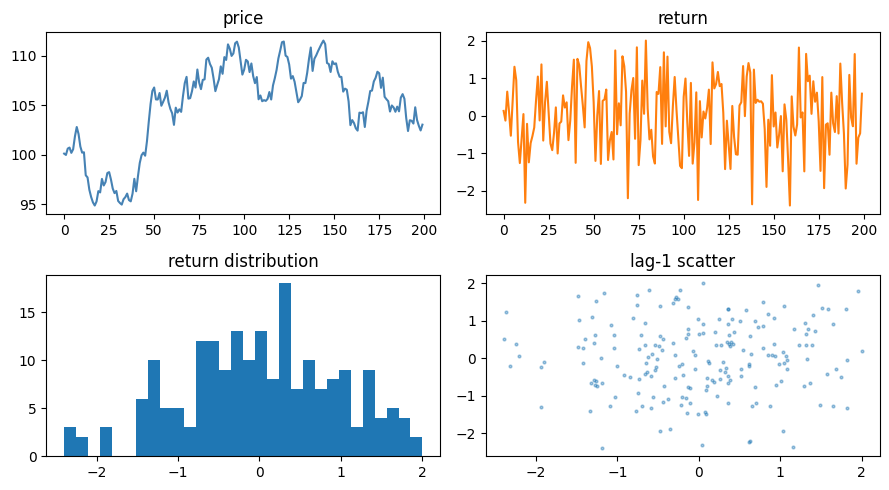

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(9, 5))

axes[0, 0].plot(prices.values, color='steelblue'); axes[0, 0].set_title('price')
axes[0, 1].plot(returns.values, color='C1');       axes[0, 1].set_title('return')
axes[1, 0].hist(returns.values, bins=30);           axes[1, 0].set_title('return distribution')
axes[1, 1].scatter(returns.values[:-1], returns.values[1:], s=4, alpha=0.4)
axes[1, 1].set_title('lag-1 scatter')

plt.tight_layout(); plt.show()

*When to use `axes.ravel()`*: when you want `for ax in axes.ravel(): ...` rather than nested `axes[i, j]` indexing. *Common mistake*: with `subplots(1, 2)`, the result is a 1D array, not 2D — `axes[0]` and `axes[1]`, not `axes[0, 0]`.


### How do I set a global figure size and font size?

`plt.rcParams` for global defaults, or `figsize=` per figure.


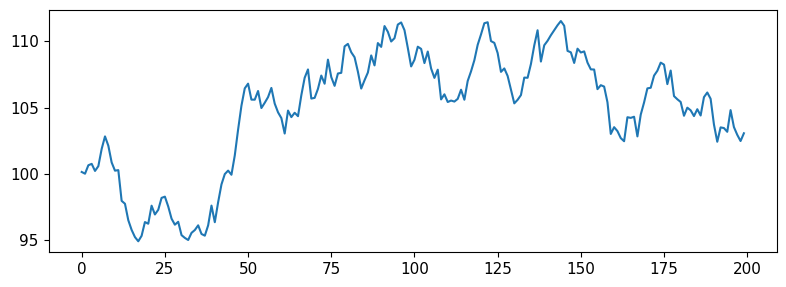

In [4]:
plt.rcParams.update({
    'figure.figsize': (8, 3),       # default size for all figures hereafter
    'font.size': 11,
    'axes.titlesize': 12,
})
fig, ax = plt.subplots()             # uses the new default size
ax.plot(prices.values); plt.tight_layout(); plt.show()
plt.rcParams.update(plt.rcParamsDefault)   # reset

*When to use rcParams*: at the top of a notebook to standardise every figure. *Common mistake*: setting rcParams and forgetting — produces strange-looking plots in unrelated cells. Reset to default at the end if you've changed them.


---
## 2. Common chart types

Line plots, scatters, bars, histograms — the everyday building blocks. Each takes the same `ax` and produces output you can further customise with `ax.set_*` methods.


### How do I plot a scatter with transparency?

`ax.scatter(x, y, s=size, alpha=0.5)`. `alpha` matters for dense data — without it scatter plots become solid blobs.


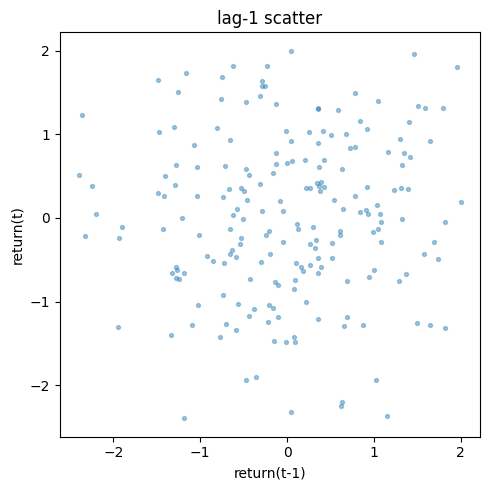

In [5]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(returns.values[:-1], returns.values[1:], s=8, alpha=0.4)
ax.set_xlabel('return(t-1)'); ax.set_ylabel('return(t)')
ax.set_title('lag-1 scatter')
plt.tight_layout(); plt.show()

*Common mistake*: `s=8` sets the *area* of each marker in points². For visible points in dense plots, try s in [4, 30]; for sparse, s in [40, 200].


### How do I plot a histogram?

`ax.hist(x, bins=30)`. Pass `density=True` for a normalised PDF estimate.


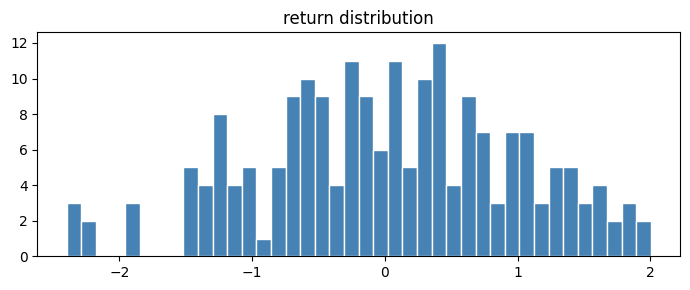

In [6]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(returns.values, bins=40, color='steelblue', edgecolor='white')
ax.set_title('return distribution')
plt.tight_layout(); plt.show()

*When to use density=True*: comparing two histograms with different sample sizes. Without it, the larger sample dominates.


### How do I plot a bar chart?

`ax.bar(x, y)` for vertical, `ax.barh(y, x)` for horizontal. Categorical axis labels go to the corresponding tick locations.


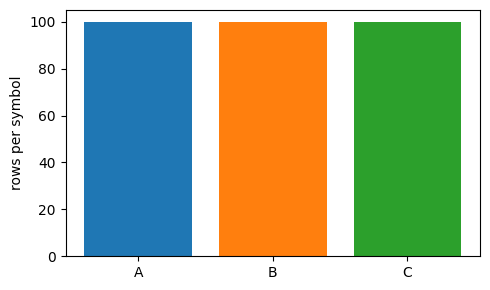

In [7]:
counts = df_long.groupby('symbol').size()
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(counts.index, counts.values, color=['C0', 'C1', 'C2'])
ax.set_ylabel('rows per symbol')
plt.tight_layout(); plt.show()

*Common mistake*: passing two integer arrays — works, but axis ticks read as numbers not categories. Use the index/string for categorical labels.


### How do I add a horizontal / vertical reference line?

`ax.axhline(y, ...)` / `ax.axvline(x, ...)`.


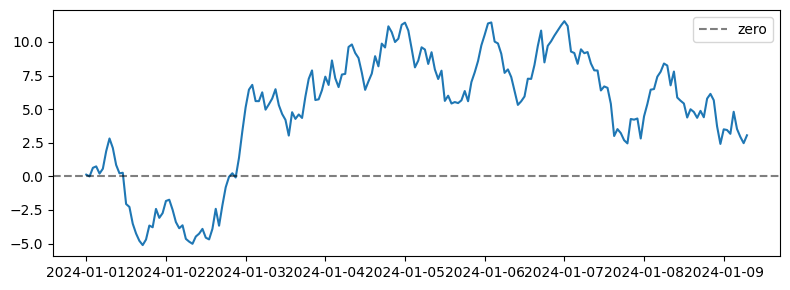

In [8]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(returns.index, returns.values.cumsum(), color='C0')
ax.axhline(0, color='black', ls='--', alpha=0.5, label='zero')
ax.legend(); plt.tight_layout(); plt.show()

*When to use*: marking the no-skill baseline (AUC=0.5), zero-return reference, target threshold.


### How do I overlay two series on the same plot?

Just call `ax.plot` twice. Add a `label=` to each and call `ax.legend()`.


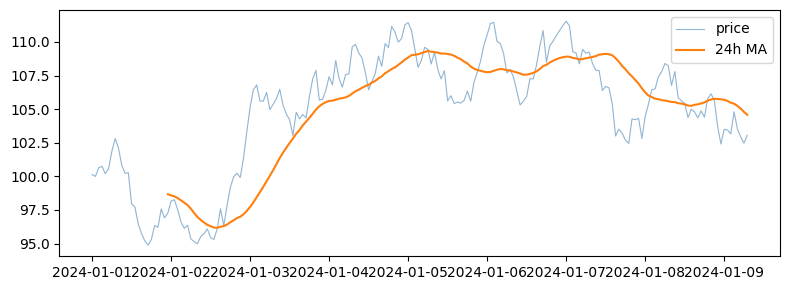

In [9]:
ma = prices.rolling(24).mean()

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(prices.index, prices.values, color='steelblue', lw=0.8, alpha=0.6, label='price')
ax.plot(ma.index, ma.values, color='C1', lw=1.5, label='24h MA')
ax.legend(); plt.tight_layout(); plt.show()

*Common mistake*: forgetting `label=` and trying to legend later — `ax.legend()` would have no entries.


---
## 3. Time-axis formatting

Plotting against a DatetimeIndex usually does the right thing, but rotating tick labels and choosing the right tick frequency takes a couple of tricks.


### How do I rotate x-axis tick labels?

`fig.autofmt_xdate()` rotates and right-aligns date ticks; `plt.setp(ax.get_xticklabels(), rotation=...)` for non-date axes.


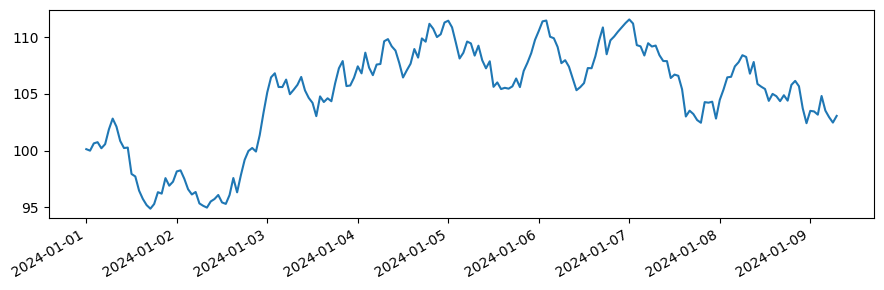

In [10]:
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(prices.index, prices.values)
fig.autofmt_xdate()           # rotates date ticks 30°, right-aligns
plt.tight_layout(); plt.show()

*When to use*: any time x-axis tick labels are getting cramped or overlapping. *Common mistake*: rotating but not aligning — slanted left-aligned labels look broken.


### How do I set a specific tick frequency on a date axis?

Use `matplotlib.dates` locators and formatters.


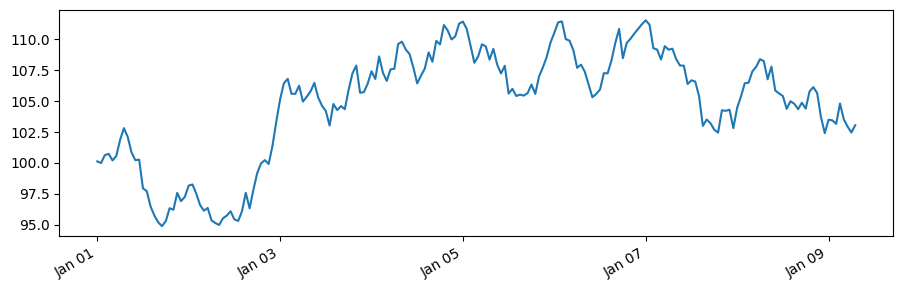

In [11]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(prices.index, prices.values)
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
fig.autofmt_xdate()
plt.tight_layout(); plt.show()

*When to use*: when matplotlib's automatic tick choice gives you too few or too many ticks. *Common mistake*: setting the locator without a matching formatter — date strings come out in unreadable defaults.


---
## 4. Twin axes and overlays

When you want to compare two series with different scales (e.g. price and volume), use a twin y-axis. When you need a small inset, use `inset_axes`.


### How do I plot two series with different y-scales on the same x-axis?

`ax.twinx()` returns a new axis sharing the x-axis. Use distinct colours and label both.


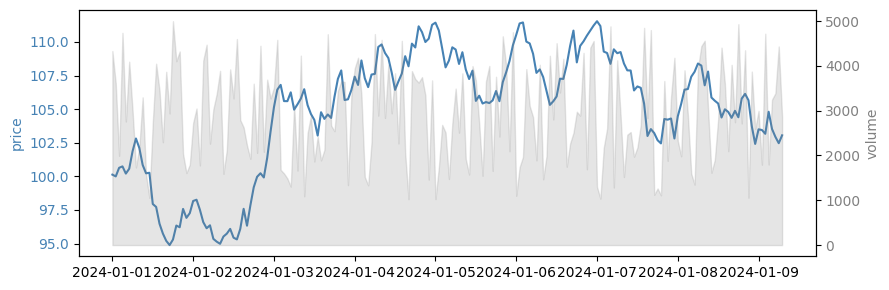

In [12]:
volume = pd.Series(rng.uniform(1000, 5000, len(ts)), index=ts)

fig, ax1 = plt.subplots(figsize=(9, 3))
ax1.plot(prices.index, prices.values, color='steelblue', label='price')
ax1.set_ylabel('price', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.fill_between(volume.index, 0, volume.values, color='gray', alpha=0.2, label='volume')
ax2.set_ylabel('volume', color='gray')
ax2.tick_params(axis='y', labelcolor='gray')

plt.tight_layout(); plt.show()

*Common mistake*: not colouring the y-axis labels — readers can't tell which axis belongs to which series. Match each axis label colour to its line.


---
## 5. Seaborn — quick statistical plots

Seaborn is matplotlib with sensible defaults for tidy data. Use it when you want a boxplot, heatmap, pairplot, or kde *quickly*; drop down to matplotlib if you need fine control.


### How do I make a boxplot grouped by a category?

`sns.boxplot(data=df, x='group', y='value')`. Operates on long-format data.


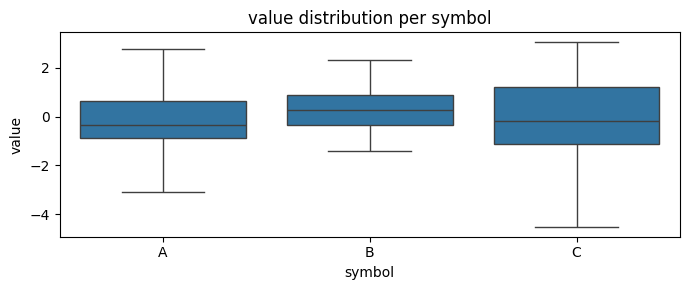

In [13]:
fig, ax = plt.subplots(figsize=(7, 3))
sns.boxplot(data=df_long, x='symbol', y='value', ax=ax, showfliers=False)
ax.set_title('value distribution per symbol')
plt.tight_layout(); plt.show()

*Why showfliers=False*: outliers usually dominate the y-axis range and obscure the boxes. Drop them for the bulk of the distribution. *Common mistake*: passing wide-format data — seaborn wants one row per observation with a column for the grouping variable.


### How do I make a heatmap?

`sns.heatmap(matrix, annot=True, cmap=...)`. Pass a 2D DataFrame; row/column labels are picked up automatically.


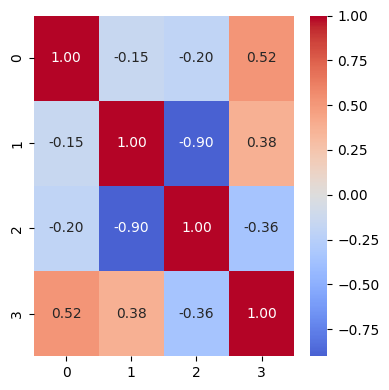

In [14]:
corr = pd.DataFrame(rng.normal(0, 1, (4, 4))).corr()
fig, ax = plt.subplots(figsize=(4, 4))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
plt.tight_layout(); plt.show()

*When to use*: correlation matrices, confusion matrices, any 2D categorical-cross. *Common mistake*: forgetting `center=0` on a correlation matrix — the colour scale becomes asymmetric and misleads.


### How do I make a kernel density (KDE) plot?

`sns.kdeplot(data=df, x='value', hue='group')` overlays smoothed densities per group.


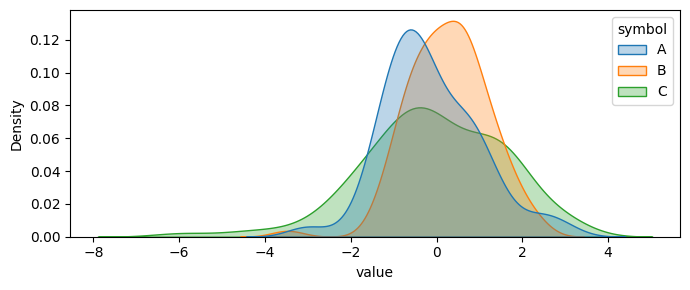

In [15]:
fig, ax = plt.subplots(figsize=(7, 3))
sns.kdeplot(data=df_long, x='value', hue='symbol', ax=ax, fill=True, alpha=0.3)
plt.tight_layout(); plt.show()

*When to use*: comparing two/three distributions on a single axis. Better than overlaying histograms (which have arbitrary bin choices).


### How do I make a pairplot of multiple numeric columns?

`sns.pairplot(df)`. Slow on big data — sample first.


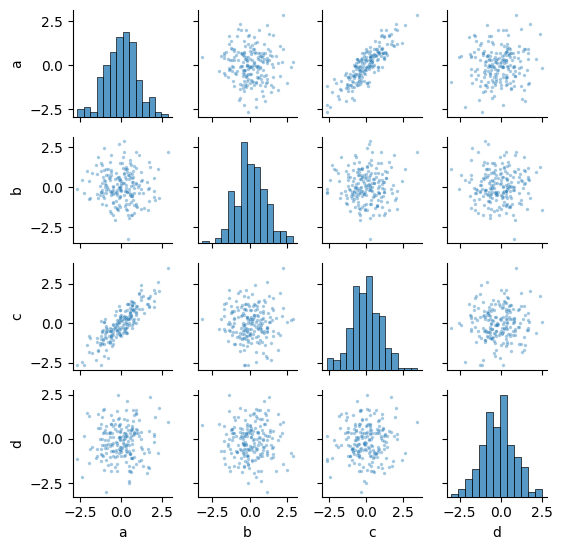

In [16]:
df_pair = pd.DataFrame(rng.normal(0, 1, (200, 4)), columns=['a', 'b', 'c', 'd'])
df_pair['c'] = df_pair['a'] + 0.5 * rng.normal(0, 1, 200)   # correlate a-c
sns.pairplot(df_pair, height=1.4, plot_kws={'s': 6, 'alpha': 0.4})
plt.tight_layout(); plt.show()

*When to use*: quick visual scan for correlations and distribution shapes across a small (≤6) set of features. *Common mistake*: pairplot on 30 columns — produces a 900-cell grid that's unreadable. Subsample to important features first.


---
## 6. Saving and styling

Saving figures to disk and making them look right outside the notebook.


### How do I save a figure to a file?

`fig.savefig('out.png', dpi=150, bbox_inches='tight')`.


In [17]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(prices.index, prices.values, color='C0')
ax.set_title('price')
plt.tight_layout()
fig.savefig('/tmp/demo_plot.png', dpi=150, bbox_inches='tight')
print('saved /tmp/demo_plot.png')
plt.close(fig)

saved /tmp/demo_plot.png


*Why bbox_inches='tight'*: matplotlib's default has whitespace around the figure; this trims it. *Common mistake*: saving inside a notebook *after* `plt.show()` closes the figure — `savefig` then writes a blank file. Save before `show()` or use the `fig` object.


### How do I change the colour palette?

Set `plt.rcParams['axes.prop_cycle']` or use `seaborn.set_palette`. Or per-line via `color='...'`.


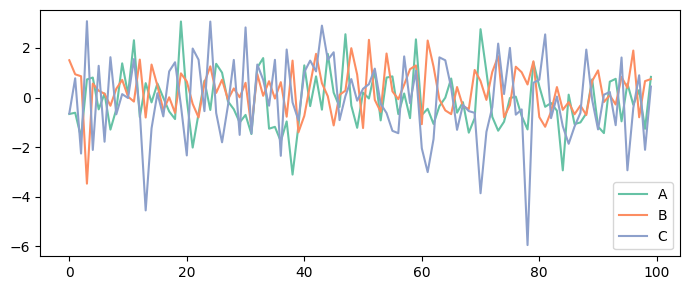

In [18]:
sns.set_palette('Set2')   # a colorblind-safe categorical palette
fig, ax = plt.subplots(figsize=(7, 3))
for sym, group in df_long.groupby('symbol'):
    ax.plot(group['value'].values, label=sym)
ax.legend()
plt.tight_layout(); plt.show()
sns.set_palette('tab10')   # back to default

*Common palettes*: `'tab10'` (default, 10 distinct colours), `'Set2'` (softer, colourblind-safe), `'viridis'` (continuous gradient). *Common mistake*: using a sequential palette for categorical data — readers will infer ordering that doesn't exist.


---
## 7. More: annotations, log axes, errors, polish

Five small additions that turn 'a chart' into 'a chart someone wants to look at'.


### How do I label specific points on a chart?

`ax.annotate(text, xy=(x, y), xytext=(...), arrowprops={...})`.


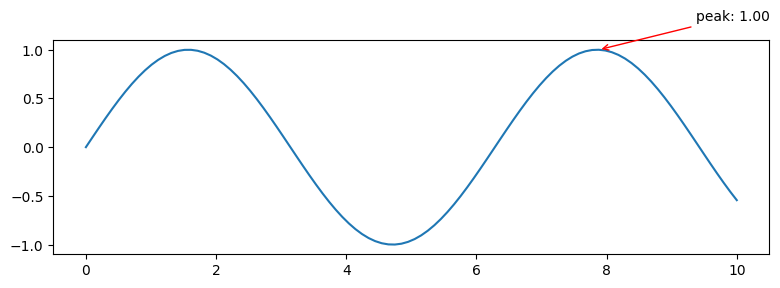

In [19]:
import matplotlib.pyplot as plt
import numpy as np

t = np.linspace(0, 10, 100)
y = np.sin(t)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(t, y)

# Annotate the global maximum.
i = int(np.argmax(y))
ax.annotate(
    f'peak: {y[i]:.2f}',
    xy=(t[i], y[i]),
    xytext=(t[i] + 1.5, y[i] + 0.3),
    arrowprops=dict(arrowstyle='->', color='red'),
    fontsize=10,
)
plt.tight_layout(); plt.show()

*When to use*: drawing the reader's eye to specific events on a time-series chart (crashes, regime changes, unusual ticks). *Common mistake*: `xytext=` uses data coordinates by default, not figure fraction — pick a location near the point you're annotating.


### How do I use a logarithmic axis?

`ax.set_yscale('log')` (or `'symlog'` for data spanning negative + positive).


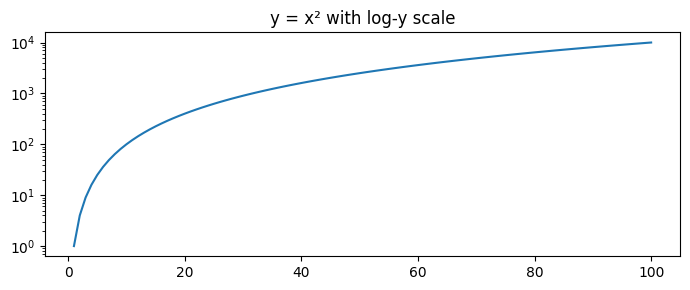

In [20]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(1, 101)
y = x ** 2

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(x, y, label='linear axes — looks parabolic')
ax.set_yscale('log')   # now the line looks straight (log y vs linear x)
ax.set_title('y = x² with log-y scale')
plt.tight_layout(); plt.show()

*When to use*: heavy-tailed quantities (return magnitudes, drawdowns, prices over long horizons), power-law relationships. *Common mistake*: log scale on data that includes zero — fails. Use `'symlog'` (symmetric log) when values cross zero.


### How do I plot with error bars or confidence bands?

`ax.errorbar(x, y, yerr=...)` for points; `ax.fill_between(x, lo, hi, alpha=0.3)` for a band.


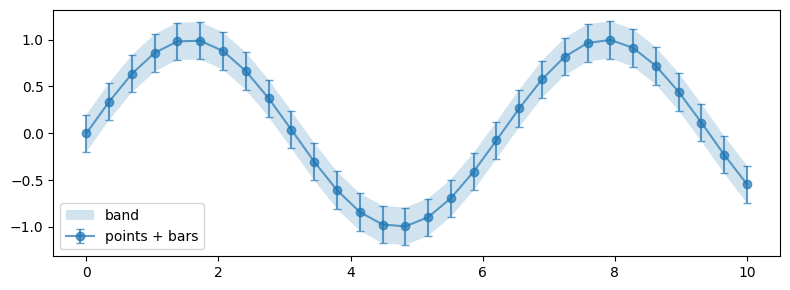

In [21]:
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(0, 10, 30)
y = np.sin(x)
yerr = 0.2 * np.ones_like(x)

fig, ax = plt.subplots(figsize=(8, 3))
ax.errorbar(x, y, yerr=yerr, fmt='o-', capsize=3, alpha=0.7, label='points + bars')

# Or as a continuous band.
ax.fill_between(x, y - yerr, y + yerr, alpha=0.2, label='band')
ax.legend(); plt.tight_layout(); plt.show()

*When to use which*: discrete measurements with uncertainty → `errorbar`. Smooth predictions with confidence interval → `fill_between`. *Common mistake*: passing `yerr` as a single number when you have asymmetric bounds — pass a 2×N array `[[lower], [upper]]`.


### Which colormap should I use?

Three families. **Categorical** for unordered classes. **Sequential** for monotone numeric. **Diverging** for data centered on a meaningful midpoint (e.g. correlations).


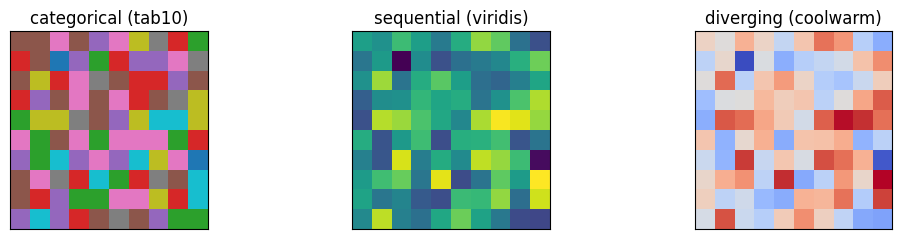

In [22]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(11, 2.5))
for ax, cmap, title in zip(axes, ['tab10', 'viridis', 'coolwarm'],
                              ['categorical (tab10)', 'sequential (viridis)', 'diverging (coolwarm)']):
    img = ax.imshow(np.random.default_rng(0).standard_normal((10, 10)), cmap=cmap)
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

*Rule*: never use rainbow (`'jet'`) — perceptually misleading. *When to use*: tab10/Set2 for groups, viridis/plasma for monotone, coolwarm/RdBu for ±-centred (correlation matrices, residuals). *Common mistake*: sequential cmap on diverging data — readers infer ordering that misrepresents the structure.


### How do I make plots look cleaner (remove spines / ticks)?

`ax.spines['top'].set_visible(False)`. Standard convention: hide top + right.


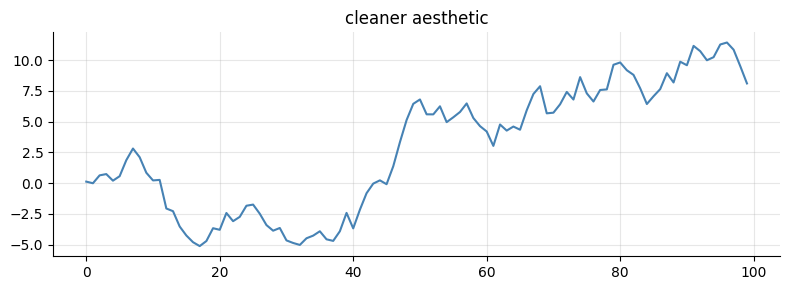

In [23]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(np.cumsum(np.random.default_rng(0).normal(0, 1, 100)), color='steelblue')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, alpha=0.3)
ax.set_title('cleaner aesthetic'); plt.tight_layout(); plt.show()

*Why*: removes visual clutter. Top + right spines add nothing in most plots. *Common mistake*: hiding all spines and the bottom axis — readers can no longer judge x-axis position; keep at least bottom + left.
